In [1]:
%matplotlib inline
import pathlib

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from adjustText import adjust_text

sns.set(style="white")

font = {"family": "Songti SC", "size": "10.5"}
plt.figure(figsize=(6.4, 4.8))
plt.rc("font", **font)
plt.rc("axes", unicode_minus=False)

flatui = ["#DF7A5E", "#F0C986", "#82B29A", "#3C405B"]
flatui_2 = ["#DF7A5E", "#3C405B"]
palette = sns.light_palette("seagreen", as_cmap=True)

common_tick_params = dict(
    direction="in",
    length=4,
    width=1.5,
    colors="black",
    grid_color="black",
    grid_alpha=0.5,
)

africa_region = {"E": "东部非洲", "W": "西部非洲", "S": "南部非洲", "C": "中部非洲"}
abbreviation = {"SSA": "撒哈拉以南非洲", "LMY": "中低收入国家", "HIC": "高收入国家", "WLD": "全球"}
abbreviation_2 = {"SSA": "撒哈拉以南非洲", "LMY": "中低收入国家", "HIC": "高收入国家", "OWID_WRL": "全球"}

dfgeo = pd.read_excel(
    pathlib.Path.home()
    / "OneDrive"
    / "Rawdata"
    / "Country Classification"
    / "UN Classification_Natural resources_Geography.xlsx",
    sheet_name="Sheet1",
    na_values="..",
    usecols="D, E, F, H",
)

output = pathlib.Path.home() / "OneDrive" / "PhD Dissertation" / "Pictures"

<Figure size 640x480 with 0 Axes>

In [2]:
# 选取“世界”的数据
df_world = pd.read_csv(
    "/Users/hanyu/OneDrive/Rawdata/World Bank World Development Index/WDI_csv/WDIData.csv",
    na_values="..",
)
df_world = (
    df_world.drop(columns=["Country Name", "Indicator Code"])
    .rename(columns={"Country Code": "Alpha-3 code"})
    .query(
        '`Alpha-3 code` == "WLD" | `Alpha-3 code` == "SSA"|`Alpha-3 code` == "LMY"| `Alpha-3 code` == "HIC"'
    )
    # .drop(columns=["Unnamed: 67"])
    .melt(id_vars=("Alpha-3 code", "Indicator Name"))
    .astype({"variable": "int64", "value": "float64"})
    .pivot_table(
        columns="Indicator Name",
        values="value",
        index=["Alpha-3 code", "variable"],
        dropna="..",
    )
    .reset_index()
    .rename(columns={"variable": "Year"})
    .query("Year>2000 & Year<=2020")
)

df_world.to_excel(
    pathlib.Path.home()
    / "OneDrive"
    / "PhD Dissertation"
    / "Data_Code"
    / "Data"
    / "df_world.xlsx",
    index=True,
)

df = pd.read_excel(
    pathlib.Path.home()
    / "OneDrive"
    / "PhD Dissertation"
    / "Data_Code"
    / "Data"
    / "index_data.xlsx"
)

<Figure size 640x480 with 0 Axes>

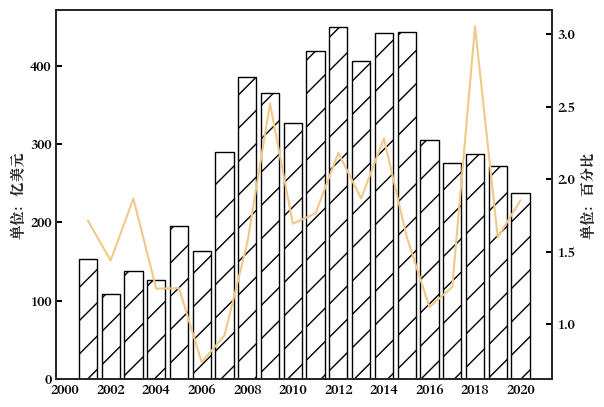

In [3]:
#################2001~2019年非洲FDI流量及占全球FDI比重趋势图
data = df_world[
    [
        "Alpha-3 code",
        "Year",
        "Foreign direct investment, net inflows (BoP, current US$)",
    ]
]
data1 = data.query('`Alpha-3 code`=="SSA"').rename(
    columns={"Foreign direct investment, net inflows (BoP, current US$)": "FDI_SSA"}
)
data2 = data1.merge(
    data.query('`Alpha-3 code`=="WLD"'), how="left", on=["Year"]
).rename(
    columns={"Foreign direct investment, net inflows (BoP, current US$)": "FDI_WLD"}
)

data2["percent"] = (data2["FDI_SSA"] / data2["FDI_WLD"]) * 100


plt.figure(figsize=(6.4, 4.8))
sns.set_style(style=None, rc=None)
fig, ax1 = plt.subplots(1, 1)


ax1.bar(
    data2["Year"],
    data2["FDI_SSA"] / 100_000_000,
    color="white",
    edgecolor="black",
    hatch="/",
)
ax1.set_ylabel("单位：亿美元", size=10.5)
ax1.tick_params(**common_tick_params)

ax2 = ax1.twinx()
ax2.plot(data2["Year"], data2["percent"], color="#F0C986")

ax2.tick_params(**common_tick_params)
ax2.set_ylabel("单位：百分比", size=10.5)

plt.xticks(range(2000, 2021, 2))
plt.xlabel("")


plt.savefig(output / "2005~2020年非洲FDI流量及占全球FDI比重趋势图.png", dpi=300, bbox_inches="tight")

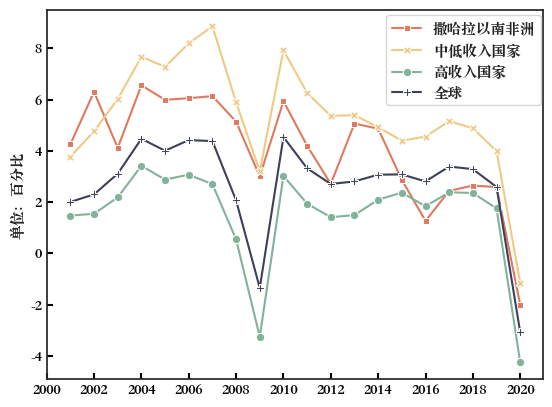

In [4]:
# 2001~2019年非洲FDI、中低收入国家、高收入国家及全球GDP增长率趋势图
plt.figure(figsize=(6.4, 4.8))
sns.set_palette(flatui)
ax = sns.lineplot(
    x="Year",
    y="GDP growth (annual %)",
    err_style=None,
    hue="Alpha-3 code",
    hue_order=abbreviation.keys(),
    style="Alpha-3 code",
    dashes=False,
    legend=False,
    markers=True,
    data=df_world,
)

ax.legend(
    abbreviation.values(),
    loc="best",
    bbox_to_anchor=(0.67, 0.722),
    ncol=1,
    fontsize=10.5,
)
ax.tick_params(left=True, right=False, bottom=True, top=False, **common_tick_params)

ax.set_xticks(range(2000, 2021, 2))
ax.set_ylabel("单位：百分比", size=10.5)
ax.set_xlabel("")

plt.savefig(
    output / "2005~2020年非洲FDI、发展中国家及全球GDP增长率趋势图.png", dpi=300, bbox_inches="tight"
)

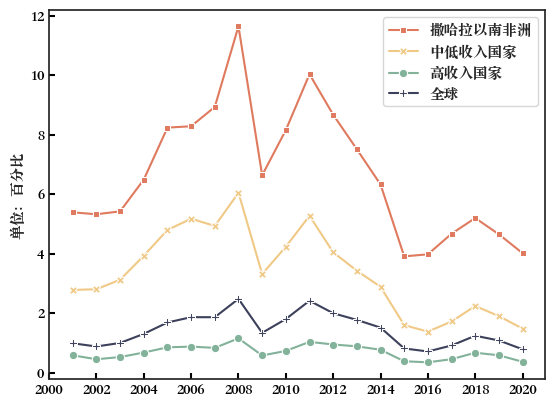

In [5]:
plt.figure(figsize=(6.4, 4.8))
sns.set_palette(flatui)
ax = sns.lineplot(
    x="Year",
    y="Adjusted savings: natural resources depletion (% of GNI)",
    err_style=None,
    hue="Alpha-3 code",
    hue_order=abbreviation.keys(),
    style="Alpha-3 code",
    dashes=False,
    legend=False,
    markers=True,
    data=df_world,
)

ax.legend(
    abbreviation.values(),
    loc="best",
    # bbox_to_anchor=(0.67, 0.722),
    ncol=1,
    fontsize=10.5,
)
ax.tick_params(left=True, right=False, bottom=True, top=False, **common_tick_params)

ax.set_xticks(range(2000, 2021, 2))
ax.set_ylabel("单位：百分比", size=10.5)
ax.set_xlabel("")
plt.savefig(output / "2005~2020年非洲、发展中国家及全球自然资源损耗趋势图.png", dpi=300, bbox_inches="tight")

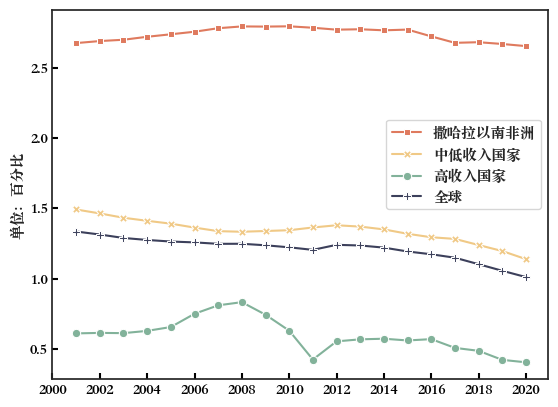

In [6]:
plt.figure(figsize=(6.4, 4.8))
sns.set_palette(flatui)
ax = sns.lineplot(
    x="Year",
    y="Population growth (annual %)",
    err_style=None,
    hue="Alpha-3 code",
    hue_order=abbreviation.keys(),
    style="Alpha-3 code",
    dashes=False,
    legend=False,
    markers=True,
    data=df_world,
)

ax.legend(
    abbreviation.values(),
    loc="best",
    bbox_to_anchor=(1, 0.722),
    ncol=1,
    fontsize=10.5,
)
ax.tick_params(left=True, right=False, bottom=True, top=False, **common_tick_params)

ax.set_xticks(range(2000, 2021, 2))
ax.set_ylabel("单位：百分比", size=10.5)
ax.set_xlabel("")
plt.savefig(output / "2005~2020年非洲、发展中国家及全球人口增长率趋势图.png", dpi=300, bbox_inches="tight")

/Users/hanyu/.pyenv/versions/miniconda3-latest/envs/africa/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


Text(0.5, 32.06249999999997, '男性平均寿命')

<Figure size 640x480 with 0 Axes>

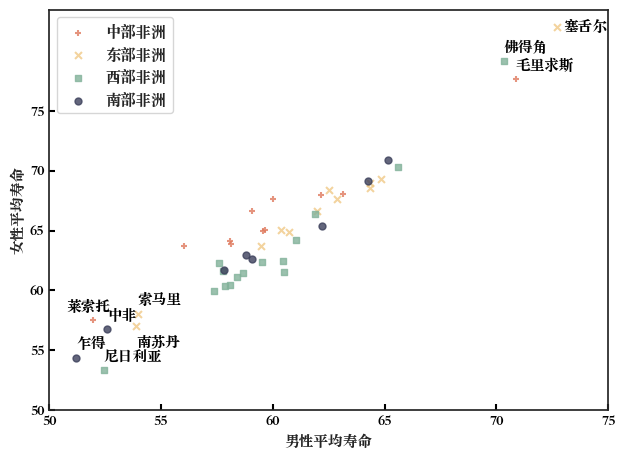

In [7]:
import pathlib

import requests_cache
import wbgapi as wb

requests_cache.install_cache()
route = pathlib.Path.home() / "OneDrive" / "Rawdata"
countrycode = pd.read_excel(
    route / "Country Code" / "Countrycode.xlsx",
    sheet_name="Sheet1",
    na_values="..",
)
life_exp = wb.data.DataFrame(
    ["SP.DYN.LE00.FE.IN", "SP.DYN.LE00.MA.IN", "SP.DYN.LE00.IN"],
    wb.region.members("SSF"),
    2020,
)


data = (
    life_exp.merge(countrycode, left_index=True, right_on="Alpha-3 code")
    .merge(dfgeo, on="Numeric")
    .set_index("CountryName_CN")
    .query("Region != 'N'")
    .rename(columns={"SP.DYN.LE00.FE.IN": "女性平均寿命", "SP.DYN.LE00.MA.IN": "男性平均寿命"})[
        ["女性平均寿命", "男性平均寿命", "Region"]
    ]
)
data["地区"] = data["Region"].str.translate(str.maketrans(africa_region))

plt.figure(figsize=(6.4, 4.8))
sns.set_palette(flatui)

ax = sns.lmplot(
    x="男性平均寿命",
    y="女性平均寿命",
    hue="地区",
    legend=False,
    markers=["+", "x", "s", "o"],
    fit_reg=False,
    scatter_kws={"s": 25},
    data=data,
    height=4.8,
    aspect=6.4 / 4.8,
)
sns.despine(top=False, right=False, left=False, bottom=False)
for z, r in data.iterrows():
    lem = r["男性平均寿命"]
    lef = r["女性平均寿命"]
    if lem > 67 or lem < 55:
        if z == "南苏丹":
            x = lem
            y = lef - 1.7
        elif z == "莱索托":
            x = lem - 1.2
            y = lef + 0.8
        elif z == "塞舌尔":
            x = lem + 0.3
            y = lef - 0.3
        else:
            x = lem
            y = lef + 0.8
        plt.text(
            x,
            y,
            z,
            horizontalalignment="left",
            size="medium",
            color="black",
            weight="semibold",
        )

plt.tick_params(
    left=True,
    bottom=True,
    **common_tick_params,
)
plt.legend(["中部非洲", "东部非洲", "西部非洲", "南部非洲"], loc="upper left")
plt.xticks(range(50, 80, 5))
plt.yticks(range(50, 80, 5))
plt.ylabel("女性平均寿命", size=10.5)
plt.xlabel("男性平均寿命", size=10.5)

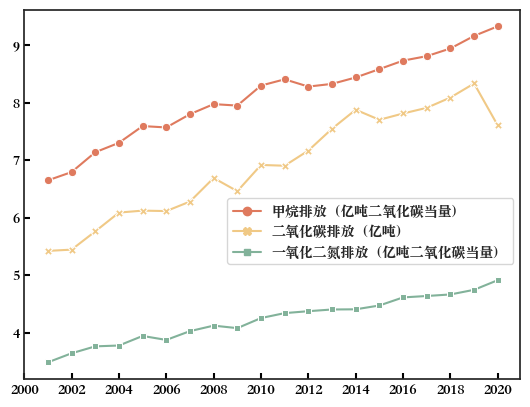

In [8]:
plt.figure(figsize=(6.4, 4.8))
sns.set_palette(flatui)

df_ssa = df_world.query('`Alpha-3 code`=="SSA"')[
    [
        "Year",
        "Methane emissions (kt of CO2 equivalent)",
        "CO2 emissions (kt)",
        "Nitrous oxide emissions (thousand metric tons of CO2 equivalent)",
    ]
].rename(
    columns={
        "Methane emissions (kt of CO2 equivalent)": "甲烷排放（亿吨二氧化碳当量）",
        "CO2 emissions (kt)": "二氧化碳排放（亿吨）",
        "Nitrous oxide emissions (thousand metric tons of CO2 equivalent)": "一氧化二氮排放（亿吨二氧化碳当量）",
    }
)
df_ssa[["甲烷排放（亿吨二氧化碳当量）", "二氧化碳排放（亿吨）", "一氧化二氮排放（亿吨二氧化碳当量）"]] /= 100_000

ax = sns.lineplot(
    data=pd.melt(df_ssa, ["Year"]).rename(columns={"Indicator Name": "指标"}),
    x="Year",
    y="value",
    hue="指标",
    # hue_order=abbreviation.keys(),
    style="指标",
    # dashes=False,
    # legend=False,
    markers=True,
    dashes=False,
)
ax.set(xlabel="", ylabel="", xticks=range(2005, 2021))
ax.legend(
    loc="center right",
    bbox_to_anchor=(1, 0.4),
    ncol=1,
    fontsize=10,
)
ax.tick_params(left=True, right=False, bottom=True, top=False, **common_tick_params)

ax.set_xticks(range(2000, 2021, 2))
plt.savefig(output / "2005~2020年撒哈拉以南非洲环境污染趋势图.png", dpi=300, bbox_inches="tight")

In [9]:
d = (
    df_world[
        [
            "Year",
            "Alpha-3 code",
            "Agriculture, forestry, and fishing, value added (% of GDP)",
            "Industry (including construction), value added (% of GDP)",
            "Services, value added (% of GDP)",
        ]
    ]
    .query("Year==2005| Year==2020")
    .query("`Alpha-3 code` =='SSA'")
)
d

Indicator Name,Year,Alpha-3 code,"Agriculture, forestry, and fishing, value added (% of GDP)","Industry (including construction), value added (% of GDP)","Services, value added (% of GDP)"
171,2005,SSA,15.024557,28.647864,48.925171
186,2020,SSA,18.277846,26.241632,49.318196


In [10]:
d2 = (
    df_world[
        [
            "Year",
            "Alpha-3 code",
            "Agriculture, forestry, and fishing, value added (current US$)",
            "Industry (including construction), value added (current US$)",
            "Services, value added (current US$)",
            "GDP (current US$)",
        ]
    ]
    .query("Year==2005| Year==2020")
    .query("`Alpha-3 code` =='SSA'")
)
d2["GDP"] = (
    d2["Agriculture, forestry, and fishing, value added (current US$)"]
    + d2["Industry (including construction), value added (current US$)"]
    + d2["Services, value added (current US$)"]
)
d2["agri"] = (
    d2["Agriculture, forestry, and fishing, value added (current US$)"] / d2["GDP"]
)
d2["indu"] = (
    d2["Industry (including construction), value added (current US$)"] / d2["GDP"]
)
d2["serv"] = d2["Services, value added (current US$)"] / d2["GDP"]
d2.round(4)

Indicator Name,Year,Alpha-3 code,"Agriculture, forestry, and fishing, value added (current US$)","Industry (including construction), value added (current US$)","Services, value added (current US$)",GDP (current US$),GDP,agri,indu,serv
171,2005,SSA,1.235590e+11,2.355940e+11,4.023500e+11,8.223780e+11,7.615030e+11,0.1623,0.3094,0.5284
186,2020,SSA,3.130760e+11,4.494850e+11,8.447570e+11,1.712870e+12,1.607318e+12,0.1948,0.2796,0.5256


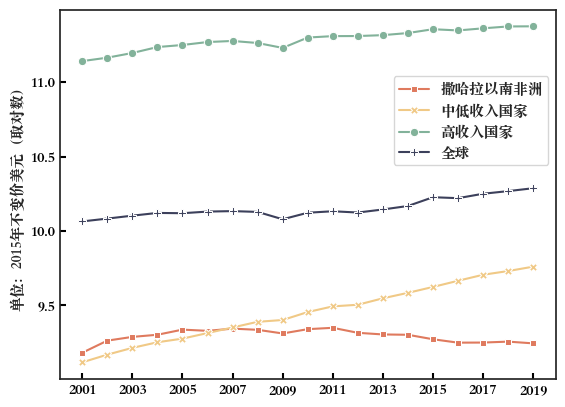

In [11]:
plt.figure(figsize=(6.4, 4.8))
sns.set_palette(flatui)

df_ssa = df_world[
    [
        "Year",
        "Alpha-3 code",
        "Industry (including construction), value added per worker (constant 2015 US$)",
    ]
].rename(
    columns={
        "Industry (including construction), value added per worker (constant 2015 US$)": "工业",
    }
)
df_ssa["工业"] = np.log(df_ssa["工业"])

ax = sns.lineplot(
    data=df_ssa,
    x="Year",
    y="工业",
    err_style=None,
    hue="Alpha-3 code",
    hue_order=abbreviation.keys(),
    style="Alpha-3 code",
    dashes=False,
    legend=False,
    markers=True,
)

ax.legend(
    abbreviation.values(),
    loc="center right",
    bbox_to_anchor=(1, 0.7),
    ncol=1,
    fontsize=10.5,
)
ax.tick_params(left=True, right=False, bottom=True, top=False, **common_tick_params)

ax.set_xticks(range(2001, 2021, 2))
ax.set_ylabel("单位：2015年不变价美元（取对数）", size=10.5)
ax.set_xlabel("")
plt.savefig(output / "2005~2020年撒哈拉以南工业增加值每工人趋势图.png", dpi=300, bbox_inches="tight")

In [12]:
df = df_world
df

Indicator Name,Alpha-3 code,Year,ARI treatment (% of children under 5 taken to a health provider),Access to clean fuels and technologies for cooking (% of population),"Access to clean fuels and technologies for cooking, rural (% of rural population)","Access to clean fuels and technologies for cooking, urban (% of urban population)",Access to electricity (% of population),"Access to electricity, rural (% of rural population)","Access to electricity, urban (% of urban population)",Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+),...,"Vulnerable employment, total (% of total employment) (modeled ILO estimate)","Wage and salaried workers, female (% of female employment) (modeled ILO estimate)","Wage and salaried workers, male (% of male employment) (modeled ILO estimate)","Wage and salaried workers, total (% of total employment) (modeled ILO estimate)",Wanted fertility rate (births per woman),"Water productivity, total (constant 2015 US$ GDP per cubic meter of total freshwater withdrawal)",Wholesale price index (2010 = 100),Women Business and the Law Index Score (scale 1-100),Women's share of population ages 15+ living with HIV (%),Young people (ages 15-24) newly infected with HIV
41,HIC,2001,NaN,99.955849,99.849203,99.988770,99.765439,99.283548,99.903016,NaN,...,11.715850,86.586421,82.498738,84.255096,NaN,37.763000,NaN,71.185345,NaN,NaN
42,HIC,2002,NaN,99.957850,99.852927,99.989445,99.775683,99.310244,99.904149,NaN,...,11.443168,87.094598,82.669275,84.575601,NaN,38.480562,NaN,72.737069,NaN,NaN
43,HIC,2003,NaN,99.959846,99.857137,99.990199,99.817601,99.469740,99.908509,NaN,...,11.393657,87.316188,82.519758,84.593336,NaN,39.307366,NaN,73.997845,NaN,NaN
44,HIC,2004,NaN,99.961843,99.861786,99.990944,99.790150,99.356703,99.905856,NaN,...,11.199423,87.503809,82.633409,84.741871,NaN,40.637270,NaN,75.290948,NaN,NaN
45,HIC,2005,NaN,99.963924,99.867206,99.991622,99.795041,99.376555,99.907290,NaN,...,11.049089,87.732418,82.846987,84.964444,NaN,41.847225,NaN,75.786638,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,WLD,2016,NaN,65.005668,40.535873,85.187388,88.192385,79.374793,96.931473,NaN,...,44.425942,53.292708,51.654387,52.291734,NaN,19.705855,NaN,73.292763,53.4,540000.0
246,WLD,2017,NaN,66.321819,42.620744,85.625663,89.019548,80.878608,97.178744,68.5,...,44.075500,53.718605,51.901065,52.606699,NaN,20.230923,NaN,73.815789,53.5,510000.0
247,WLD,2018,NaN,67.696517,44.757756,86.105891,89.893733,82.109088,97.075178,NaN,...,43.530770,54.305745,52.363358,53.114329,NaN,20.949604,NaN,74.509868,53.6,480000.0
248,WLD,2019,NaN,68.921601,46.977355,86.443383,90.194716,82.747305,97.321186,NaN,...,43.356716,54.298792,52.707316,53.327825,NaN,21.425971,NaN,75.378289,53.7,450000.0


In [13]:
d = df[
    [
        "Alpha-3 code",
        "Year",
        "Employment in agriculture (% of total employment) (modeled ILO estimate)",
        "Employment in industry (% of total employment) (modeled ILO estimate)",
        "Employment in services (% of total employment) (modeled ILO estimate)",
    ]
].query("`Alpha-3 code` == 'SSA'")
d["sum"] = (
    d["Employment in agriculture (% of total employment) (modeled ILO estimate)"]
    + d["Employment in industry (% of total employment) (modeled ILO estimate)"]
    + d["Employment in services (% of total employment) (modeled ILO estimate)"]
)
d["indu"] = (
    d["Employment in services (% of total employment) (modeled ILO estimate)"]
    / d["sum"]
)
d

Indicator Name,Alpha-3 code,Year,Employment in agriculture (% of total employment) (modeled ILO estimate),Employment in industry (% of total employment) (modeled ILO estimate),Employment in services (% of total employment) (modeled ILO estimate),sum,indu
167,SSA,2001,61.671599,10.147427,28.180975,100.000001,0.281810
168,SSA,2002,61.345300,10.232073,28.422628,100.000000,0.284226
169,SSA,2003,60.987302,10.254619,28.758084,100.000005,0.287581
170,SSA,2004,60.545715,10.336089,29.118196,100.000000,0.291182
171,SSA,2005,60.269505,10.279548,29.450947,100.000001,0.294509
172,SSA,2006,59.600741,10.279528,30.119726,99.999996,0.301197
173,SSA,2007,58.902319,10.259900,30.837779,99.999998,0.308378
174,SSA,2008,58.354631,10.026840,31.618540,100.000011,0.316185
175,SSA,2009,57.819255,10.009506,32.171246,100.000007,0.321712
176,SSA,2010,57.040870,10.064819,32.894308,99.999997,0.328943


In [14]:
(1 + 0.0397) ** 19 * 8653

18130.907372853835

In [15]:
d2 = df[
    [
        "Alpha-3 code",
        "Year",
        "Adjusted savings: natural resources depletion (% of GNI)",
    ]
].query("`Alpha-3 code` == 'SSA'")
# d2["Foreign direct investment, net inflows (BoP, current US$)"] = (
#     d2["Foreign direct investment, net inflows (BoP, current US$)"] / 1_0000_0000
# )
# d2 = ((
#     d2.query("Year==2001 | Year==2020").set_index(["Alpha-3 code", "Year"])
#     .groupby("Alpha-3 code")
#     .pct_change()
#     .query("Year==2020")
#     #.sort_values("Foreign direct investment, net inflows (BoP, current US$)")
# )+ 1)** (1 / 19)- 1
d2

Indicator Name,Alpha-3 code,Year,Adjusted savings: natural resources depletion (% of GNI)
167,SSA,2001,5.391983
168,SSA,2002,5.328650
169,SSA,2003,5.425006
170,SSA,2004,6.492702
171,SSA,2005,8.238866
172,SSA,2006,8.285090
173,SSA,2007,8.933811
174,SSA,2008,11.642726
175,SSA,2009,6.637438
176,SSA,2010,8.156205


In [16]:
from pathlib import Path

route = Path.home() / "OneDrive" / "PhD Dissertation" / "Data_Code" / "Data"
if not route.exists():
    route.mkdir(parents=True)

df_final = pd.read_csv(
    Path.home() / "OneDrive" / "Rawdata" / "Data cleaning" / "df_final.csv"
).set_index(["Numeric", "Year"])
df_final = df_final.sort_index(level=["Numeric", "Year"])
df_final.drop(
    [col for col in df_final.columns if col.endswith("_y")], axis=1, inplace=True
)
years = list(range(2001, 2021))

country = pd.read_excel(
    route / "Variables Selection" / "Variables Chosen.xlsx",
    sheet_name="Countries",
    na_values="..",
)
dfgeo = pd.read_excel(
    Path.home()
    / "OneDrive"
    / "Rawdata"
    / "Country Classification"
    / "UN Classification_Natural resources_Geography.xlsx",
    sheet_name="Sheet1",
    na_values="..",
    usecols="D, E",
).query("Region!= 'N'")
country = country.merge(dfgeo, on=["Numeric"])

/var/folders/6v/nc250lnx4qs4c1hjd2jt44_00000gn/T/ipykernel_46879/2148280355.py:7: DtypeWarning: Columns (1483,1612,1613,1658,1660,1663,1680,1783,1784,1786,1788,2313,2380,2390,2392,2394,2395,2398,2451,4826,4827,4828,4829,4830,4831,4832,4833,4834,4835,4836,4837,4838,4839) have mixed types. Specify dtype option on import or set low_memory=False.
  df_final = pd.read_csv(


In [17]:
data_raw = (
    df_final.query("Year in @years")
    .reset_index()
    .astype({"Numeric": int, "Year": int})
    .merge(country[["Numeric", "CountryName_CN"]], on="Numeric")
    .rename(columns={"CountryName_CN_y": "CountryName_CN"})
)

In [18]:
d = (
    (
        (
            data_raw[["CountryName_CN", "Year", "GDP (constant 2015 US$)_x"]]
            .query("Year==2001 | Year==2020")
            .set_index(["CountryName_CN", "Year"])
            .groupby("CountryName_CN")
            .pct_change()
            .query("Year==2020")
            .sort_values("GDP (constant 2015 US$)_x")
        )
        + 1
    )
    ** (1 / 19)
    - 1
).reset_index()

# data_raw[["CountryName_CN", "Year", "GDP (constant 2015 US$)_x"]].query(
#     "Year==2020"
# ).set_index(["CountryName_CN", "Year"]).sort_values(
#     "GDP (constant 2015 US$)_x"
# ) / 100_0000_0000
print("、".join(d.query("`GDP (constant 2015 US$)_x`>=0.05")["CountryName_CN"].unique()))

尼日尔、尼日利亚、赞比亚、刚果（金）、布基纳法索、塞拉利昂、乍得、加纳、莫桑比克、坦桑尼亚、乌干达、卢旺达、埃塞俄比亚


In [19]:
d = (
    data_raw[["CountryName_CN","Region", "Year", "PM2.5 exposure/Ambient particulate matter pollution"]]
    # .query("Year==2005")
    .set_index(["CountryName_CN","Region", "Year"])
    .groupby("Year")
    .mean()
    .sort_values("PM2.5 exposure/Ambient particulate matter pollution")
)
d

,PM2.5 exposure/Ambient particulate matter pollution
Year,
2001,1016.457586
2002,1027.017459
2003,1032.553596
2004,1041.600321
2005,1043.358756
2006,1049.266466
2007,1058.007880
2008,1070.665436
2009,1082.969305


In [20]:
np.exp(1.56)

4.758821245137854